# Step 2 - Data Cleaning

Based on what I found in notebook 01:
- 9 columns are 100% null → drop
- Lot columns mostly empty → drop
- Valeur fonciere has French comma format and outliers up to 14 billion
- ~40% of rows have no Type local (pure land transactions)
- Date column needs parsing

Going to clean step by step and check row count after each major drop.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '../data/'

In [2]:
# reload raw data (same as notebook 01)
years = [2021, 2022, 2023, 2024, 2025]
dfs = []
for year in years:
    df = pd.read_csv(DATA_DIR + f'ValeursFoncieres-{year}.txt', sep='|', low_memory=False)
    df['annee'] = year
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
print(f'Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')

Loaded: 20,382,915 rows, 44 columns


## 1. Drop completely useless columns

In [3]:
# columns that are 100% null - no point keeping these
cols_100_null = [
    'Identifiant de document', 'Reference document',
    '1 Articles CGI', '2 Articles CGI', '3 Articles CGI', '4 Articles CGI', '5 Articles CGI',
    'Identifiant local'
]

# verify before dropping
print('Null % for these columns:')
print((df[cols_100_null].isnull().mean() * 100).round(1))

df.drop(columns=cols_100_null, inplace=True)
print(f'\nAfter drop: {df.shape[1]} columns')

Null % for these columns:


Identifiant de document    100.0
Reference document         100.0
1 Articles CGI             100.0
2 Articles CGI             100.0
3 Articles CGI             100.0
4 Articles CGI             100.0
5 Articles CGI             100.0
Identifiant local          100.0
dtype: float64

After drop: 36 columns


In [4]:
# lot columns - mostly empty and not really what we need for analysis
# 'Nombre de lots' is 0% null so keeping that one
# 'Surface Carrez du 1er lot' is 91% null but still might matter for apartments
# actually let me just drop all the lot detail columns, they're too sparse

lot_cols_to_drop = [
    '1er lot', 'Surface Carrez du 1er lot',
    '2eme lot', 'Surface Carrez du 2eme lot',
    '3eme lot', 'Surface Carrez du 3eme lot',
    '4eme lot', 'Surface Carrez du 4eme lot',
    '5eme lot', 'Surface Carrez du 5eme lot',
    'No Volume'  # 99.8% null
]

df.drop(columns=lot_cols_to_drop, inplace=True)
print(f'After lot drop: {df.shape[1]} columns')

After lot drop: 25 columns


In [5]:
# also dropping these - too sparse to be useful:
# B/T/Q: 95.5% null (some kind of batch/type/quarter code)
# Prefixe de section: 95.3% null
# Nature culture speciale: 95.7% null
# Code voie: just a code version of Voie, redundant

sparse_cols = ['B/T/Q', 'Prefixe de section', 'Nature culture speciale', 'Code voie']
df.drop(columns=sparse_cols, inplace=True)
print(f'After sparse drop: {df.shape[1]} columns')
print(df.columns.tolist())

After sparse drop: 21 columns
['No disposition', 'Date mutation', 'Nature mutation', 'Valeur fonciere', 'No voie', 'Type de voie', 'Voie', 'Code postal', 'Commune', 'Code departement', 'Code commune', 'Section', 'No plan', 'Nombre de lots', 'Code type local', 'Type local', 'Surface reelle bati', 'Nombre pieces principales', 'Nature culture', 'Surface terrain', 'annee']


## 2. Fix data types

In [6]:
# Valeur fonciere - French decimal format (comma instead of dot)
df['valeur_fonciere'] = (
    df['Valeur fonciere']
    .str.replace(',', '.', regex=False)
    .astype(float)
)
df.drop(columns=['Valeur fonciere'], inplace=True)

print('valeur_fonciere sample:')
print(df['valeur_fonciere'].describe())

valeur_fonciere sample:


count    2.018697e+07
mean     1.522759e+06
std      1.675288e+07
min      1.000000e-02
25%      6.990000e+04
50%      1.664972e+05
75%      3.097930e+05
max      1.415000e+10
Name: valeur_fonciere, dtype: float64


In [7]:
# Date mutation - parse as datetime
df['date_mutation'] = pd.to_datetime(df['Date mutation'], format='%d/%m/%Y', errors='coerce')
df.drop(columns=['Date mutation'], inplace=True)

# how many failed to parse?
bad_dates = df['date_mutation'].isnull().sum()
print(f'Failed date parses: {bad_dates}')
print(df['date_mutation'].dt.year.value_counts().sort_index())

Failed date parses: 0


date_mutation
2021    4674542
2022    4676187
2023    3817426
2024    3499931
2025    3714829
Name: count, dtype: int64


In [8]:
# rename columns to snake_case - easier to type
rename_map = {
    'No disposition': 'no_disposition',
    'Nature mutation': 'nature_mutation',
    'No voie': 'no_voie',
    'Type de voie': 'type_voie',
    'Voie': 'voie',
    'Code postal': 'code_postal',
    'Commune': 'commune',
    'Code departement': 'code_departement',
    'Code commune': 'code_commune',
    'Section': 'section',
    'No plan': 'no_plan',
    'Nombre de lots': 'nombre_lots',
    'Code type local': 'code_type_local',
    'Type local': 'type_local',
    'Surface reelle bati': 'surface_bati',
    'Nombre pieces principales': 'nb_pieces',
    'Nature culture': 'nature_culture',
    'Surface terrain': 'surface_terrain',
}

df.rename(columns=rename_map, inplace=True)
print(df.columns.tolist())

['no_disposition', 'nature_mutation', 'no_voie', 'type_voie', 'voie', 'code_postal', 'commune', 'code_departement', 'code_commune', 'section', 'no_plan', 'nombre_lots', 'code_type_local', 'type_local', 'surface_bati', 'nb_pieces', 'nature_culture', 'surface_terrain', 'annee', 'valeur_fonciere', 'date_mutation']


## 3. Handle missing values in key columns

In [9]:
# check missing after column drops
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'count': missing, 'pct': missing_pct})[missing > 0].sort_values('pct', ascending=False)

,count,pct
code_type_local,8189148,40.2
type_local,8189148,40.2
surface_bati,8201916,40.2
nb_pieces,8201916,40.2
type_voie,7941469,39.0
no_voie,7465445,36.6
nature_culture,6483813,31.8
surface_terrain,6483813,31.8
valeur_fonciere,195947,1.0
voie,139662,0.7


In [10]:
# rows with no valeur_fonciere are useless - it's the main value
before = len(df)
df = df[df['valeur_fonciere'].notna()]
print(f'Dropped {before - len(df):,} rows with null valeur_fonciere')
print(f'Remaining: {len(df):,}')

Dropped 195,947 rows with null valeur_fonciere
Remaining: 20,186,968


In [11]:
# type_local is null for ~40% - these are pure terrain/land transactions
# NOT going to drop these, they're valid just different category
# fill with 'Terrain' as a label so we can filter later
df['type_local'] = df['type_local'].fillna('Terrain')
df['type_local'].value_counts()

type_local
Terrain                                     8062465
Dépendance                                  5281525
Maison                                      3348236
Appartement                                 2853447
Local industriel. commercial ou assimilé     641295
Name: count, dtype: int64

In [12]:
# code_type_local - same thing, fill matching
df['code_type_local'] = df['code_type_local'].fillna(0).astype(int)

# surface_bati and nb_pieces - 0 makes sense for Terrain rows, fill with 0
df['surface_bati'] = df['surface_bati'].fillna(0)
df['nb_pieces'] = df['nb_pieces'].fillna(0)

# surface_terrain - same logic
df['surface_terrain'] = df['surface_terrain'].fillna(0)

print('Missing after fills:')
df.isnull().sum()[df.isnull().sum() > 0]

Missing after fills:


no_voie           7346632
type_voie         7831518
voie               139347
code_postal        139634
section               727
nature_culture    6471524
dtype: int64

In [13]:
# code_postal has 0.7% missing - not going to fill, just leave as NaN
# commune/voie also 0.7% - same
# nature_culture 31.8% - these are rows without land use type (buildings), leave as NaN
print('Remaining nulls - acceptable:')
df.isnull().sum()[df.isnull().sum() > 0]

Remaining nulls - acceptable:


no_voie           7346632
type_voie         7831518
voie               139347
code_postal        139634
section               727
nature_culture    6471524
dtype: int64

## 4. Handle outliers

In [14]:
# valeur_fonciere outliers
# max is 14 billion - clearly commercial/industrial, not residential
# median is ~166k which makes sense for France

print('Valeur fonciere distribution:')
print(df['valeur_fonciere'].describe())

print(f'\nHow many > 1M: {(df["valeur_fonciere"] > 1_000_000).sum():,}')
print(f'How many > 10M: {(df["valeur_fonciere"] > 10_000_000).sum():,}')
print(f'How many < 1000: {(df["valeur_fonciere"] < 1000).sum():,}')

Valeur fonciere distribution:


count    2.018697e+07
mean     1.522759e+06
std      1.675288e+07
min      1.000000e-02
25%      6.990000e+04
50%      1.664972e+05
75%      3.097930e+05
max      1.415000e+10
Name: valeur_fonciere, dtype: float64

How many > 1M: 1,270,761
How many > 10M: 311,906
How many < 1000: 506,172


In [15]:
# look at very cheap transactions - what are these?
df[df['valeur_fonciere'] < 100][['commune', 'nature_mutation', 'type_local', 'valeur_fonciere']].head(10)

,commune,nature_mutation,type_local,valeur_fonciere
2,BEY,Vente,Terrain,10.0
6,CORVEISSIAT,Vente,Terrain,36.3
220,CORVEISSIAT,Vente,Terrain,42.6
270,PONT-DE-VEYLE,Vente,Dépendance,1.0
370,PERONNAS,Vente,Terrain,1.0
530,BAGE-DOMMARTIN,Vente,Terrain,90.0
531,BAGE-DOMMARTIN,Vente,Terrain,90.0
1150,PONT-DE-VAUX,Vente,Terrain,20.0
1839,BOISSEY,Vente,Terrain,50.0
2464,REYSSOUZE,Vente,Terrain,68.5


In [16]:
# very cheap ones look like symbolic sales or partial rights transfers
# keeping them for now but flagging - TODO: decide later if we want to filter

# for outlier detection use IQR method on valeur_fonciere
Q1 = df['valeur_fonciere'].quantile(0.25)
Q3 = df['valeur_fonciere'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 3 * IQR  # using 3x instead of 1.5x because property prices vary a lot
upper = Q3 + 3 * IQR

print(f'Q1: {Q1:,.0f}  Q3: {Q3:,.0f}  IQR: {IQR:,.0f}')
print(f'Lower bound: {lower:,.0f}')
print(f'Upper bound: {upper:,.0f}')
print(f'Outliers above: {(df["valeur_fonciere"] > upper).sum():,}')
print(f'Outliers below: {(df["valeur_fonciere"] < lower).sum():,}')

Q1: 69,900  Q3: 309,793  IQR: 239,893
Lower bound: -649,779
Upper bound: 1,029,472
Outliers above: 1,251,821
Outliers below: 0


In [17]:
# flag outliers instead of dropping - easier to filter later
df['is_outlier_valeur'] = (df['valeur_fonciere'] > upper) | (df['valeur_fonciere'] < 1)
print(f'Flagged as outlier: {df["is_outlier_valeur"].sum():,} ({df["is_outlier_valeur"].mean()*100:.1f}%)')

Flagged as outlier: 1,252,564 (6.2%)


In [18]:
# surface_bati outliers - let's see the distribution
print(df[df['surface_bati'] > 0]['surface_bati'].describe())
print(f'\nSurface > 10000m²: {(df["surface_bati"] > 10000).sum():,}')

count    6.808686e+06
mean     1.151335e+02
std      1.016213e+03
min      1.000000e+00
25%      4.900000e+01
50%      7.500000e+01
75%      1.050000e+02
max      6.462300e+05
Name: surface_bati, dtype: float64

Surface > 10000m²: 3,329


In [19]:
# nb_pieces - sanity check
print(df['nb_pieces'].value_counts().sort_index().head(20))
print(f'\nnb_pieces > 20: {(df["nb_pieces"] > 20).sum()}')

nb_pieces
0.0     13997961
1.0       650083
2.0      1113301
3.0      1503563
4.0      1504551
5.0       873542
6.0       339456
7.0       124548
8.0        45643
9.0        17363
10.0        8100
11.0        3794
12.0        2003
13.0        1073
14.0         611
15.0         421
16.0         213
17.0         125
18.0          93
19.0          61
Name: count, dtype: int64

nb_pieces > 20: 407


## 5. Final check

In [20]:
print(f'Final shape: {df.shape}')
print(f'\nColumns:')
print(df.dtypes)
print(f'\nMissing:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Final shape: (20186968, 22)

Columns:
no_disposition                int64
nature_mutation                 str
no_voie                     float64
type_voie                       str
voie                            str
code_postal                 float64
commune                         str
code_departement                str
code_commune                  int64
section                         str
no_plan                       int64
nombre_lots                   int64
code_type_local               int64
type_local                      str
surface_bati                float64
nb_pieces                   float64
nature_culture                  str
surface_terrain             float64
annee                         int64
valeur_fonciere             float64
date_mutation        datetime64[us]
is_outlier_valeur              bool
dtype: object

Missing:


no_voie           7346632
type_voie         7831518
voie               139347
code_postal        139634
section               727
nature_culture    6471524
dtype: int64


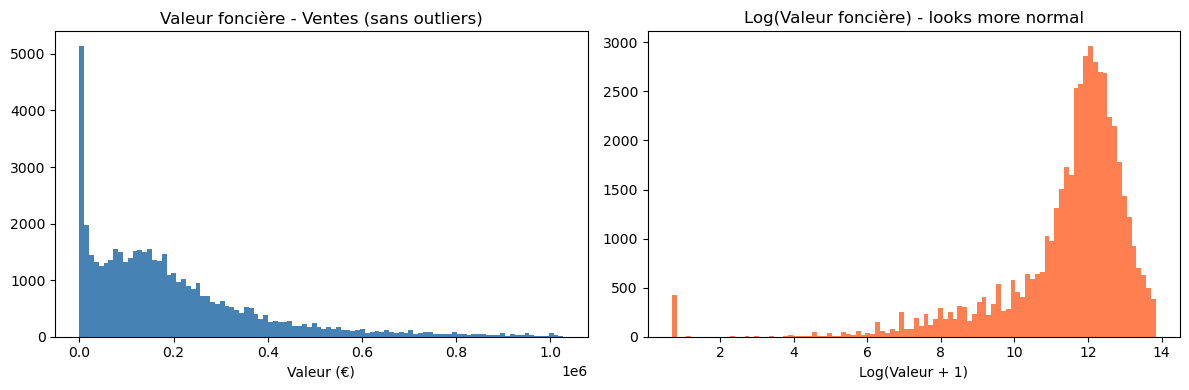

plot saved


In [21]:
# quick distribution plot to visually confirm cleaning worked
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# only non-outlier ventes (regular sales)
mask = (df['nature_mutation'] == 'Vente') & (~df['is_outlier_valeur'])
sample = df[mask]['valeur_fonciere'].sample(50000, random_state=42)

axes[0].hist(sample, bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Valeur foncière - Ventes (sans outliers)')
axes[0].set_xlabel('Valeur (€)')

axes[1].hist(np.log1p(sample), bins=100, color='coral', edgecolor='none')
axes[1].set_title('Log(Valeur foncière) - looks more normal')
axes[1].set_xlabel('Log(Valeur + 1)')

plt.tight_layout()
plt.savefig('../outputs/plots/valeur_distribution.png', dpi=100)
plt.show()
print('plot saved')

In [22]:
# save cleaned dataframe
# TODO: try parquet - csv is slow to write for 20M rows
df.to_parquet('../data/cleaned.parquet', index=False)
print(f'Saved cleaned data: {len(df):,} rows')

Saved cleaned data: 20,186,968 rows
